In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys

sys.path.append('..')

import aux_plot

In [3]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

In [4]:
history_path = '../models/trained_model_3.9_history.npy'
#history_path = '../models/trained_model_date_2024.06.07_h_11.08_history.npy'
#history_path = '../models/trained_model_date_2024.06.07_h_12.09_history.npy'
#history_path = '../models/trained_model_date_2024.06.07_h_13.03_history.npy'
#history_path = '../models/trained_model_date_2024.06.07_h_19.11_history.npy'
#history_path = '../models/trained_model_date_2024.06.07_h_22.40_history.npy'
#history_path = '../models/trained_model_date_2024.06.07_h_23.38_history.npy'
history_path = '../models/trained_model_date_2024.06.09_h_20.31_history.npy' # 3.4 (EMA solo sensore ante scalatura)
#history_path = '../models/trained_model_date_2024.06.09_h_23.09_history.npy'
history_path = '../models/trained_model_date_2024.06.09_h_23.57_history.npy'
history_path = '../models/trained_model_date_2024.06.10_h_10.37_history.npy'
history_path = '../models/trained_model_date_2024.06.10_h_11.27_history.npy'

# curriculum
history_path = '../models/trained_model_date_2024.06.10_h_12.00_history.npy' # 3.4 curriculum (sequence_len = 20 + 10 * int(i / 20))

# no curriculum
#history_path = '../models/trained_model_date_2024.06.12_h_15.23_history.npy' # no curriculum, seq_len = 20 fixed
#history_path = '../models/trained_model_date_2024.06.12_h_17.33_history.npy' # no curriculum, seq_len = 30 fixed
#history_path = '../models/trained_model_date_2024.06.12_h_18.08_history.npy' # no curriculum, seq_len = 40 fixed
#history_path = '../models/trained_model_date_2024.06.12_h_16.28_history.npy' # no curriculum, seq_len = 60 fixed

# offline augmentation
#history_path = '../models/trained_model_date_2024.06.14_h_11.35_history.npy'

history = np.load(file=history_path, allow_pickle='TRUE').item()

0.005412637608781181
0.06198656


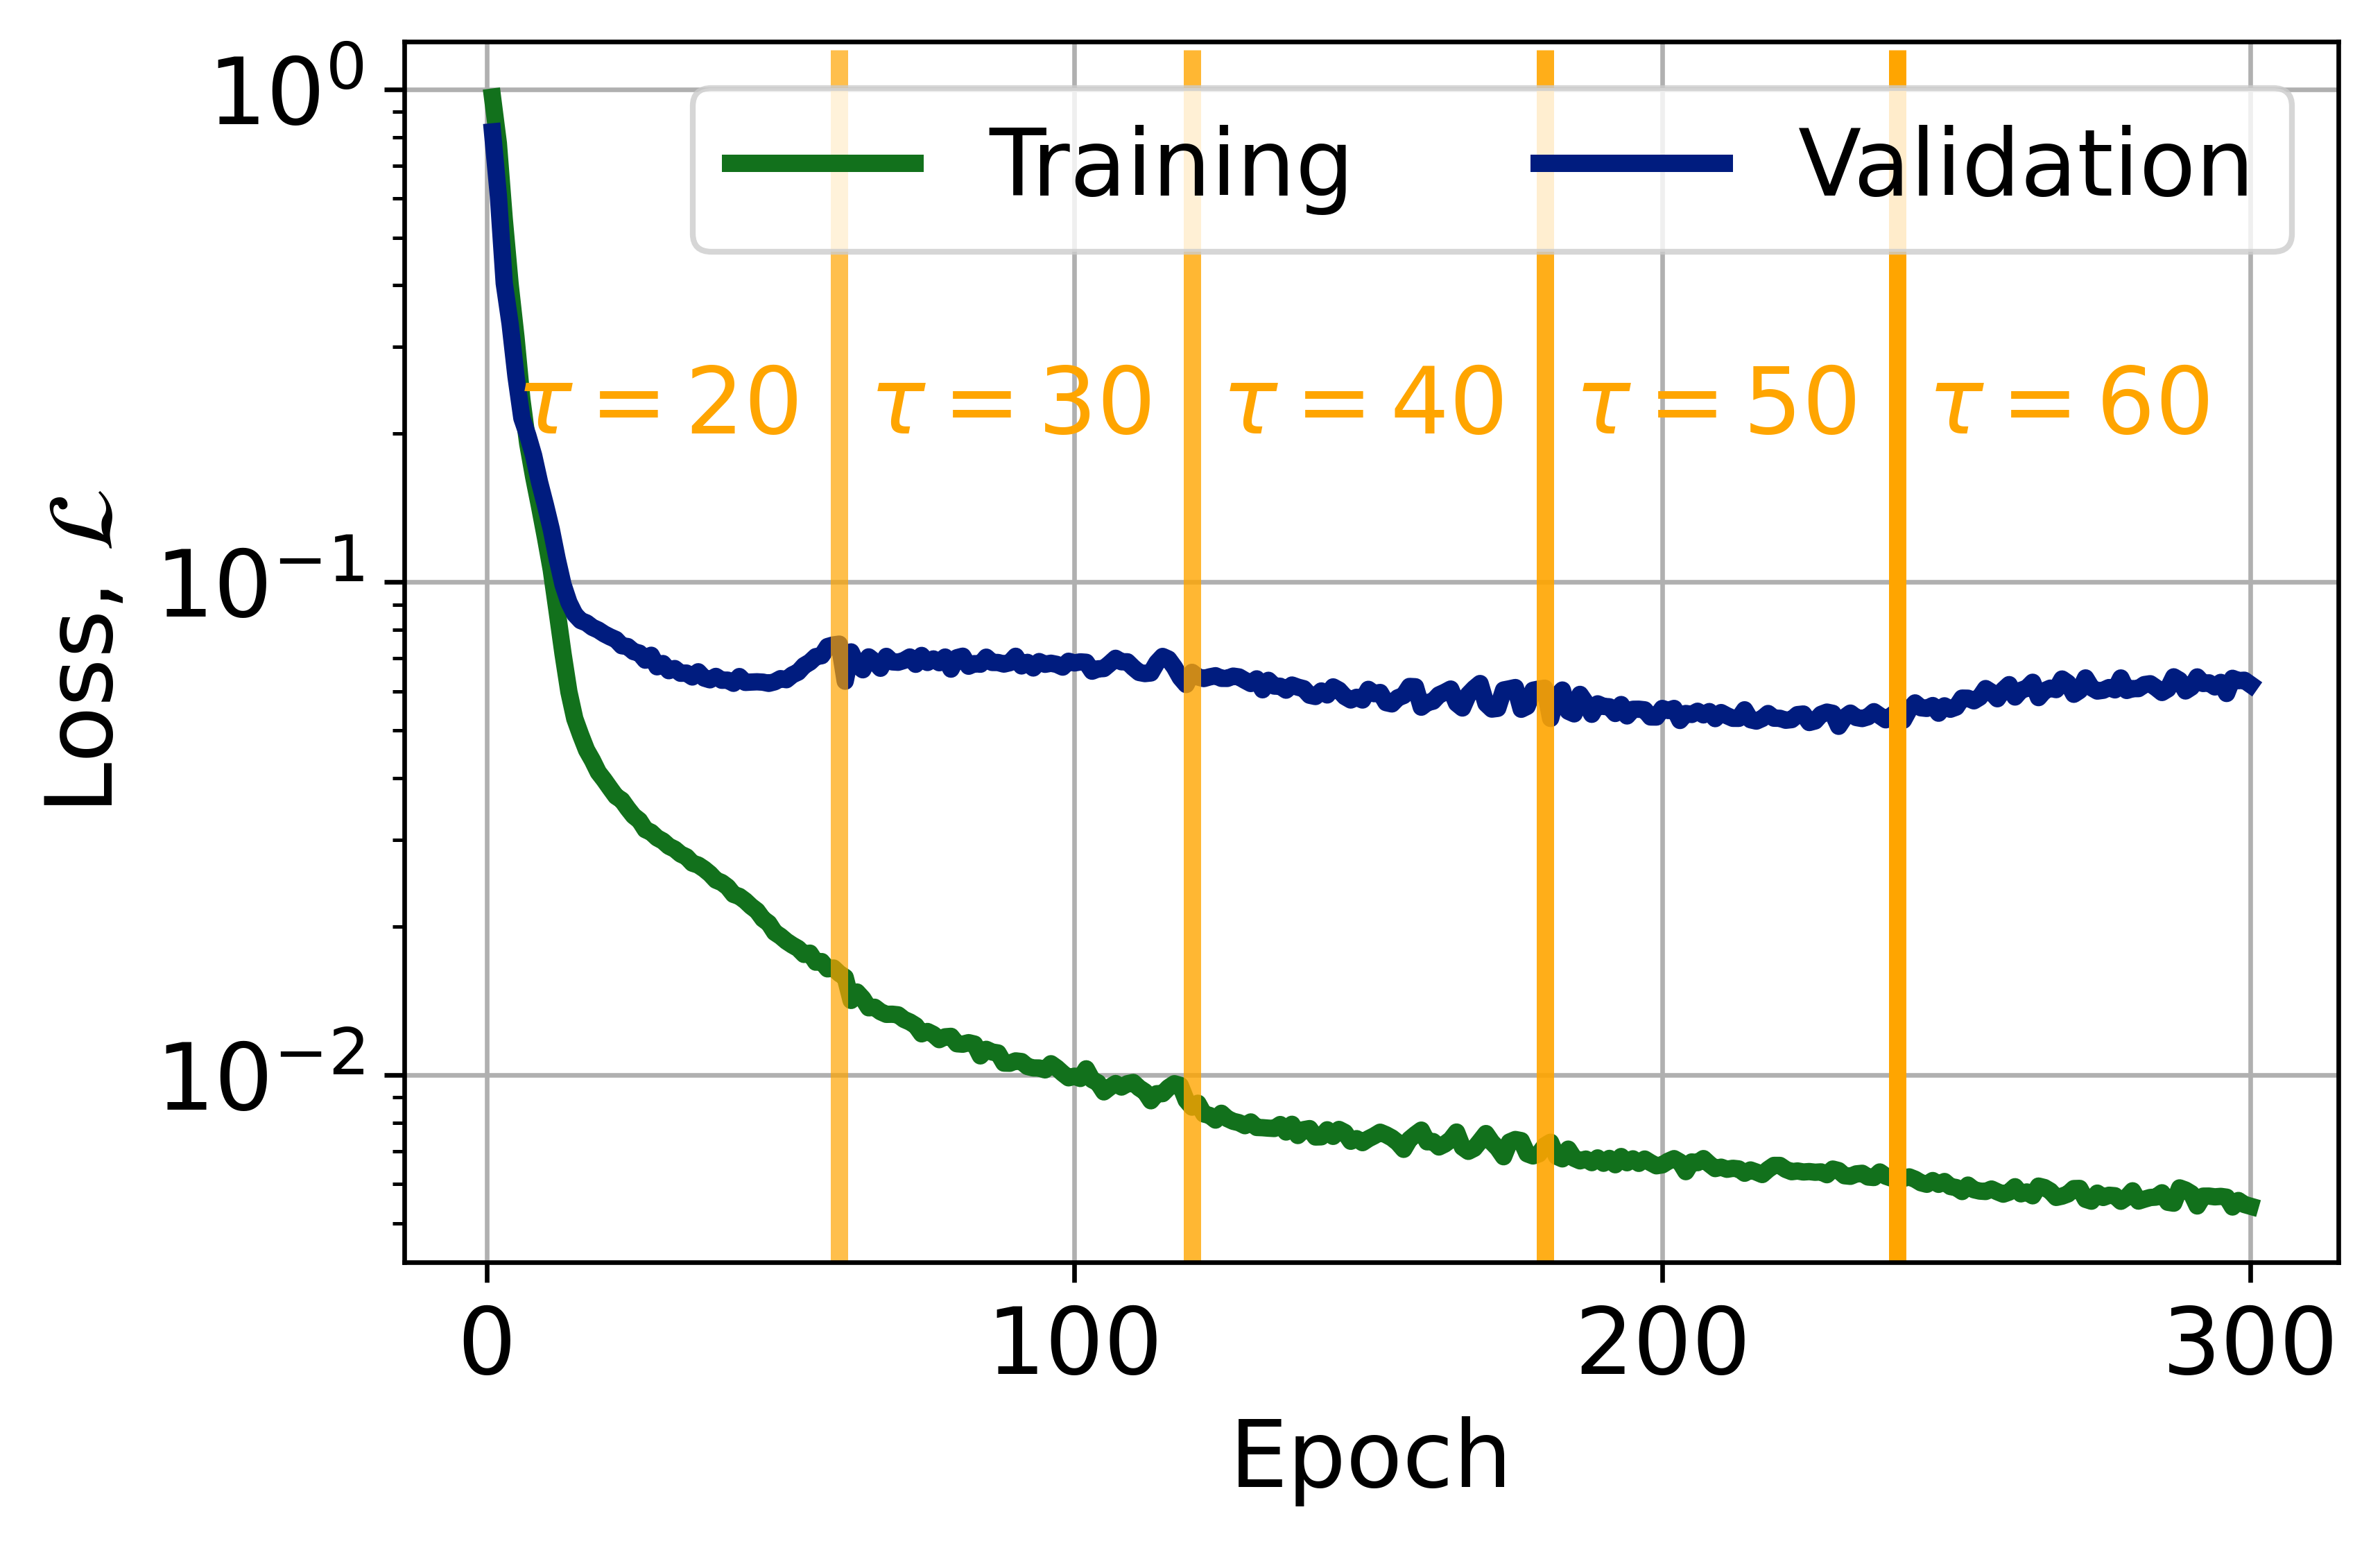

In [6]:
training_losses = np.array(history['training_losses'])
validation_losses = np.array(history['validation_losses'])

epochs = np.arange(1, len(training_losses) + 1, 1)

print(training_losses[-1])
print(validation_losses[-1])

fig = plt.figure(figsize=(6,4), dpi=600)
plt.plot(epochs, training_losses, linewidth=3, color=sns.palettes.SEABORN_PALETTES['dark'][2], label='Training')
plt.plot(epochs, validation_losses, linewidth=3, color=sns.palettes.SEABORN_PALETTES['dark'][0], label='Validation')
plt.yscale('log')

plt.vlines(x=60, ymin=0, ymax=1.2, linewidth=3, color='orange', alpha=0.7)
plt.vlines(x=120, ymin=0, ymax=1.2, linewidth=3, color='orange', alpha=0.8)
plt.vlines(x=180, ymin=0, ymax=1.2, linewidth=3, color='orange', alpha=0.9)
plt.vlines(x=240, ymin=0, ymax=1.2, linewidth=3, color='orange', alpha=1.0)
plt.annotate(text=r'$\tau=20$', xy=(0+5, 2e-1), color='orange')
plt.annotate(text=r'$\tau=30$', xy=(60+5, 2e-1), color='orange')
plt.annotate(text=r'$\tau=40$', xy=(120+5, 2e-1), color='orange')
plt.annotate(text=r'$\tau=50$', xy=(180+5, 2e-1), color='orange')
plt.annotate(text=r'$\tau=60$', xy=(240+5, 2e-1), color='orange')

plt.grid()
plt.legend(ncols=2, loc='best')
plt.xlabel('Epoch')
plt.ylabel(r'Loss, $\mathcal{L}$')
plt.tight_layout()
plt.savefig(fname='../figures/learning_curve.pdf', bbox_inches='tight')
plt.savefig(fname='../figures/learning_curve.png', bbox_inches='tight')
plt.savefig(fname='../figures/learning_curve.svg', bbox_inches='tight')
plt.show()